<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/fertilizer-scheduling-model/FerilizerSchedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from scipy.stats import linregress
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

Cleaning Data, Preprocessing data and feature engineering for Fertilizer dataset.

In [3]:
#fertilizer dataset
fert = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Fertilizer_History.csv', header=None)
fert.columns = ["Division", "Field", "Area", "Type", "Date", "Amount", "Block", "Extra"]
fert = fert.drop(columns=["Extra"]).dropna(how='all')

fert['Division'] = fert['Division'].ffill()
fert = fert[
    fert['Field'].notna() & (fert['Field'] != 0) & (fert['Field'] != '-') & (fert['Field'] != 'Field')
]
fert = fert[fert['Division'] != 'Division']

fert['Area'] = pd.to_numeric(fert['Area'], errors='coerce')
fert['Amount'] = pd.to_numeric(fert['Amount'], errors='coerce')
fert = fert.dropna(subset=['Area','Amount'])
fert['Date'] = fert['Date'].astype(str).str.replace('Sept', 'Sep', regex=False)
fert['Date'] = pd.to_datetime(fert['Date'], format='%d-%b-%y', errors='coerce')
fert = fert.dropna(subset=['Date'])
fert = fert[fert['Date'].dt.year > 2000]

fert['Month'] = fert['Date'].dt.strftime('%B')

# Feature engineering
fert['Fertilizer_per_area'] = fert['Amount'] / fert['Area']
fert = fert.sort_values(by=['Division','Field','Date']).reset_index(drop=True)
fert['Prev_Amount'] = fert.groupby(['Division','Field'])['Amount'].shift(1).fillna(0)
fert['Days_since_last'] = fert.groupby(['Division','Field'])['Date'].diff().dt.days.fillna(0)

print("Fert shape:", fert.shape)
print(fert[['Division','Field','Date','Amount']].head())

Fert shape: (65, 11)
  Division Field       Date  Amount
0      AGO    3A 2023-02-12    30.0
1      AGO    3B 2023-08-18    24.0
2      AGO    4A 2024-08-31    11.0
3      AGO    9G 2025-02-02     6.0
4      AGO    9H 2024-03-21    16.0


Cleaning Data, Preprocessing data and feature engineering for the yeild dataset.

In [4]:
#yeild dataset
yield_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Block_Metadata.csv', header=None)
yield_df = yield_df.dropna(how='all').reset_index(drop=True)
yield_df = yield_df.iloc[4:].reset_index(drop=True)

yield_df.columns = [
    'Division', 'Asst_Manager', 'Field', 'Area', 'Type',
    'Planting_Year', 'Last_Pruned', 'Age_Months'
] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]

# Cleaning numeric columns
numeric_cols = ['Area','Age_Months'] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]
for col in numeric_cols:
    yield_df[col] = pd.to_numeric(yield_df[col].astype(str).str.replace(',',''), errors='coerce')
yield_df[numeric_cols] = yield_df[numeric_cols].fillna(yield_df[numeric_cols].median())
yield_df['Division'] = yield_df['Division'].ffill()
yield_df['Field'] = yield_df['Field'].ffill()
yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)

# Feature engineering
yield_df['Yield_per_ha'] = yield_df['Year_1'] / yield_df['Area']
last_5_cols = [col for col in yield_df.columns if 'Year_' in col][:5]
yield_df['Avg_Yield_Last5Y'] = yield_df[last_5_cols].mean(axis=1)
yield_df['Yield_Trend'] = yield_df['Year_1'] - yield_df['Avg_Yield_Last5Y']
yield_df['Months_Since_Pruning'] = yield_df['Age_Months'] - ((pd.to_datetime('2025-09-01') - yield_df['Last_Pruned']).dt.days/30)
yield_df['Months_Since_Pruning'] = yield_df['Months_Since_Pruning'].fillna(yield_df['Months_Since_Pruning'].median())

yield_features = yield_df[['Division','Field','Area','Age_Months','Yield_per_ha','Avg_Yield_Last5Y','Yield_Trend','Months_Since_Pruning']]

/tmp/ipykernel_173/1387161079.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)


Cleaning Data, Preprocessing data and feature engineering for climate dataset.

In [5]:
#Climate dataset
climate = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Climate_Data.csv', header=None)
climate = climate.dropna(how='all').reset_index(drop=True)

months = ['January','February','March','April','May','June','July','August','September','October','November','December']
climate = climate[climate[0].str.strip().isin(months)].reset_index(drop=True)

n_cols = climate.shape[1]
columns = ['Month']
num_years = (n_cols - 1)//2
for i in range(num_years):
    columns += [f'Wetdays_Year_{i+1}', f'Rainfall_Year_{i+1}']
if len(columns) != n_cols:
    columns += [f'Extra_{i}' for i in range(len(columns), n_cols)]
climate.columns = columns

# Clean numeric
for col in climate.columns[1:]:
    climate[col] = pd.to_numeric(climate[col].astype(str).str.replace(',','').str.replace('-','').str.strip(), errors='coerce')
non_empty_cols = [c for c in climate.columns if climate[c].notna().sum() > 0 or c=='Month']
climate = climate[non_empty_cols]

rainfall_cols = [c for c in climate.columns if 'Rainfall' in c]
wetdays_cols = [c for c in climate.columns if 'Wetdays' in c]

climate['Rainfall_Mean'] = climate[rainfall_cols].mean(axis=1)
climate['Rainfall_Max'] = climate[rainfall_cols].max(axis=1)
climate['Rainfall_Min'] = climate[rainfall_cols].min(axis=1)
climate['Wetdays_Mean'] = climate[wetdays_cols].mean(axis=1)

def compute_trend(row):
    y = row[rainfall_cols].values.astype(float)
    valid_idx = ~np.isnan(y)
    if valid_idx.sum()<2:
        return 0
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x[valid_idx], y[valid_idx])
    return slope

climate['Rainfall_Trend'] = climate.apply(compute_trend, axis=1)

Clean, pre-process and fature engineer plucking round dataset

In [11]:
# Plucking rounds dataset
today = pd.Timestamp.today().normalize()

df_pluck = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Last_10_Year_Data_-_PLUCKING_ROUNDS_-AS_AT_JUNE-25.csv.csv', header=None)
df_pluck.columns = ['Field','Type','Extent','Rounds_2526','Rounds_2425','Rounds_2324']

division_map = {
    'AGROYA DIVISION': 'AGO', 'LOWER DANDUKELLEWA DIVISION': 'LDK',
    'LOWER VELLAI OYA DIVISION': 'LVO', 'UPPER DANDUKELLEWA DIVISION': 'UDK',
    'UPPER VELLAI OYA DIVISION': 'UVO'
}
df_pluck['Division'] = df_pluck['Field'].map(division_map).ffill()
pluck = df_pluck[~df_pluck['Field'].astype(str).str.contains(
    'Division|Estate|PLUCKING|Field|Type', na=True)].copy()
pluck = pluck[pluck['Field'].notna()].copy()

for c in ['Rounds_2526','Rounds_2425','Rounds_2324','Extent']:
    pluck[c] = pd.to_numeric(pluck[c].astype(str).str.strip().replace('-',''), errors='coerce')
pluck['Field'] = pluck['Field'].astype(str).str.strip()

# Feature engineering
pluck['Rounds_Trend']      = pluck['Rounds_2425'] - pluck['Rounds_2324']
pluck['Rounds_Pct_Change'] = ((pluck['Rounds_2425'] - pluck['Rounds_2324']) / pluck['Rounds_2324'] * 100).round(1)
pluck['Rounds_Mean']       = pluck[['Rounds_2324','Rounds_2425']].mean(axis=1)

print("Plucking rounds shape:", pluck.shape)
print(pluck[['Division','Field','Rounds_2324','Rounds_2425','Rounds_Trend','Rounds_Pct_Change']].head(10))

Plucking rounds shape: (70, 10)
   Division                        Field  Rounds_2324  Rounds_2425  \
4       AGO              AGROYA DIVISION          NaN          NaN   
5       AGO                           3A         29.0         29.0   
6       AGO                           3B         22.0         31.0   
7       AGO                           4A         30.0         21.0   
8       AGO                           9G         30.0         24.0   
9       AGO                           9H         27.0         30.0   
10      AGO                           9I         34.0         28.0   
12      LDK  LOWER DANDUKELLEWA DIVISION          NaN          NaN   
13      LDK                           44         19.0         29.0   
14      LDK                           45         32.0         30.0   

    Rounds_Trend  Rounds_Pct_Change  
4            NaN                NaN  
5            0.0                0.0  
6            9.0               40.9  
7           -9.0              -30.0  
8      

Merging the datasets


In [7]:
merged_df = pd.merge(fert, yield_features, on=['Division','Field'], how='left')
merged_df = pd.merge(merged_df, climate[['Month','Rainfall_Mean','Wetdays_Mean']], on='Month', how='left')
merged_df = pd.merge(merged_df, pluck[['Division','Field','Rounds_2324','Rounds_2425','Rounds_Trend','Rounds_Pct_Change','Rounds_Mean','Extent']], on=['Division','Field'], how='left')

num_cols = merged_df.select_dtypes(include=np.number).columns
merged_df[num_cols] = merged_df[num_cols].fillna(merged_df[num_cols].median())

print("Final Merged Dataset:")
print(merged_df.head())
print("\nShape:", merged_df.shape)
print("\nColumns:", merged_df.columns.tolist())

Final Merged Dataset:
  Division Field  Area_x Type       Date  Amount  Block     Month  \
0      AGO    3A     5.0   VP 2023-02-12    30.0    NaN  February   
1      AGO    3B     4.5   VP 2023-08-18    24.0    NaN    August   
2      AGO    4A     4.0   VP 2024-08-31    11.0    NaN    August   
3      AGO    9G     4.0   VP 2025-02-02     6.0    NaN  February   
4      AGO    9H     4.0   VP 2024-03-21    16.0    NaN     March   

   Fertilizer_per_area  Prev_Amount  ...  Yield_Trend  Months_Since_Pruning  \
0             6.000000          0.0  ...       -322.4             -0.066667   
1             5.333333          0.0  ...       -298.8              0.166667   
2             2.750000          0.0  ...       -328.8             -0.200000   
3             1.500000          0.0  ...       -553.6             -0.033333   
4             4.000000          0.0  ...       -151.4              0.366667   

   Rainfall_Mean  Wetdays_Mean  Rounds_2324  Rounds_2425  Rounds_Trend  \
0      96.0000

Performing Exploratory data analysis on the merged dataset

/tmp/ipykernel_173/1795898161.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Month', y='Yield_per_ha', hue='Division', ci=None)


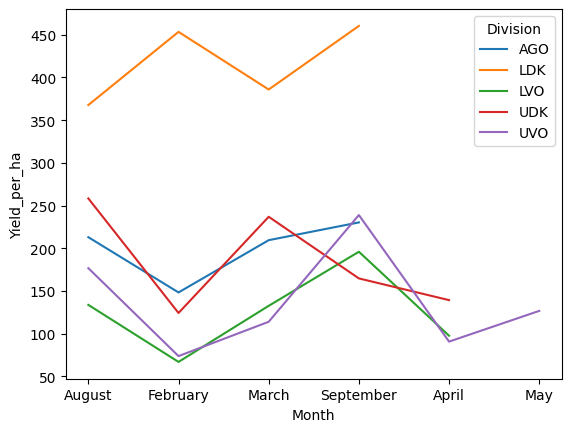

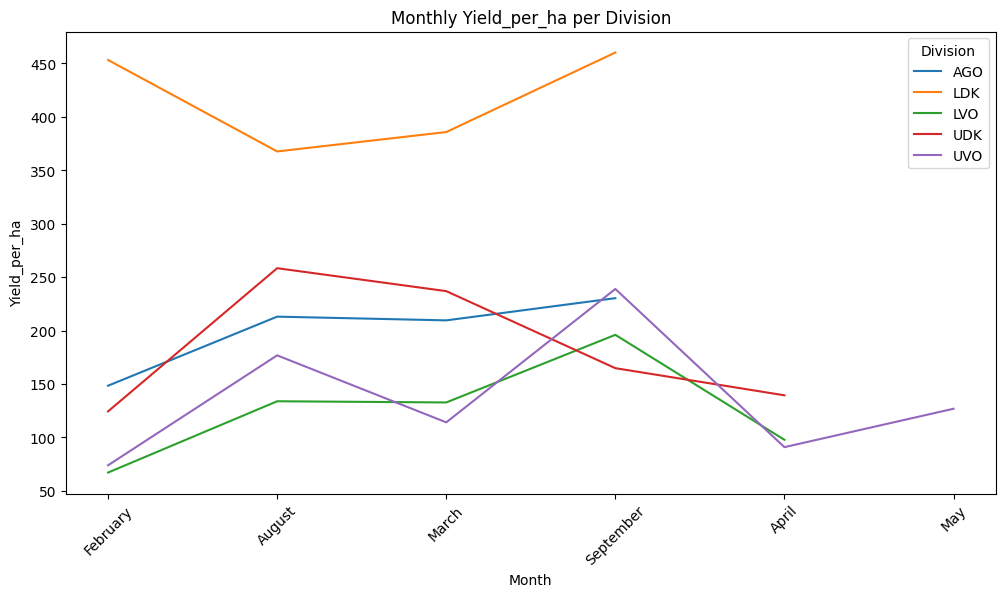

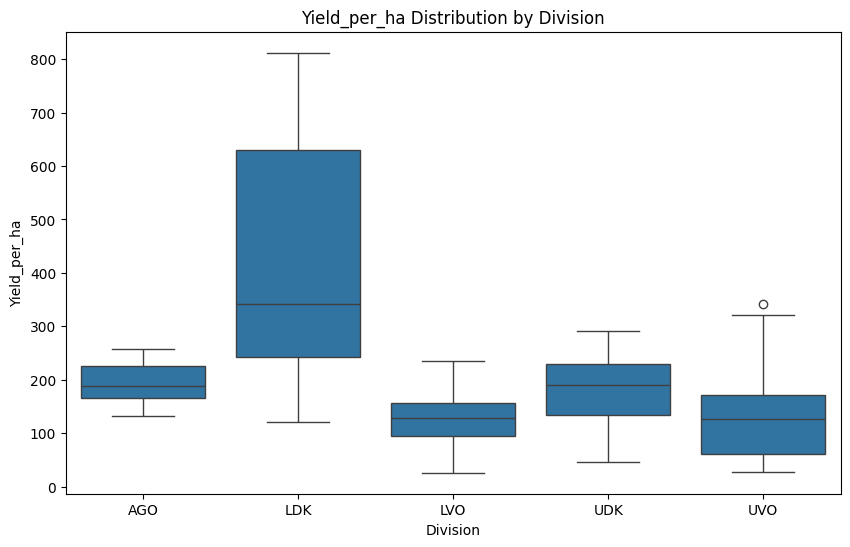

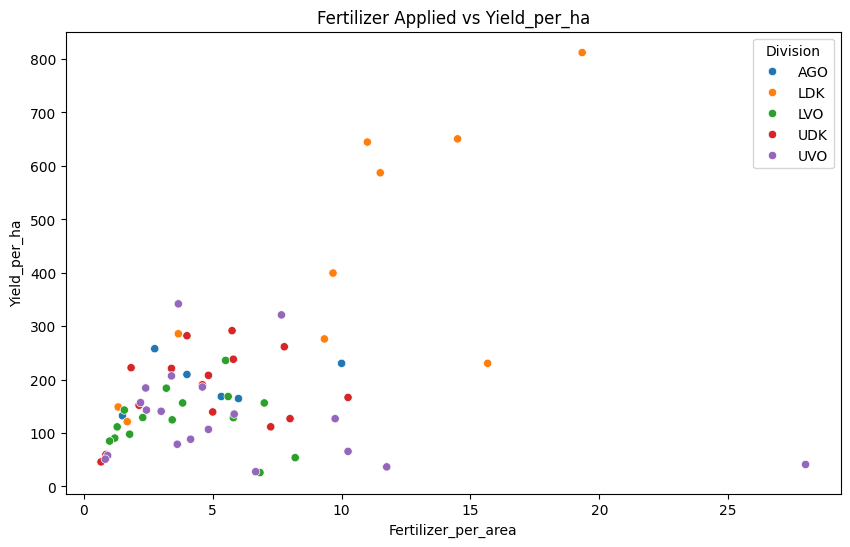


Top correlated numeric features with Yield_per_ha:
 Avg_Yield_Last5Y       0.678948
Area_x                 0.609186
Area_y                 0.609186
Extent                 0.609186
Rounds_2425            0.531675
Rounds_Mean            0.439239
Rounds_Trend           0.419709
Fertilizer_per_area    0.408427
Rounds_Pct_Change      0.370132
Name: Yield_per_ha, dtype: float64


In [8]:
df = merged_df.copy()

#Lineplot: Yield_per_ha across months per Division
df_grouped = df.groupby(['Division', 'Month'])['Yield_per_ha'].mean().reset_index()
sns.lineplot(data=df_grouped, x='Month', y='Yield_per_ha', hue='Division')
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Month', y='Yield_per_ha', hue='Division', ci=None)
plt.title("Monthly Yield_per_ha per Division")
plt.xticks(rotation=45)
plt.show()

#Boxplot: Distribution of Yield_per_ha per Division
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Division', y='Yield_per_ha')
plt.title("Yield_per_ha Distribution by Division")
plt.show()

#Scatterplot: Fertilizer_per_area vs Yield_per_ha
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Fertilizer_per_area', y='Yield_per_ha', hue='Division')
plt.title("Fertilizer Applied vs Yield_per_ha")
plt.show()

#Top correlations only
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()
top_corr = corr_matrix['Yield_per_ha'].abs().sort_values(ascending=False)[1:10]
print("\nTop correlated numeric features with Yield_per_ha:\n", top_corr)

In [18]:
# Random forest regressor to predict fertilizer amount
print("Initial Shape:", merged_df.shape)

merged_df['AmountPerHa']  = merged_df['Amount'] / merged_df['Area_x']
merged_df['Division_enc'] = LabelEncoder().fit_transform(merged_df['Division'])
merged_df['Month_Num']    = merged_df['Date'].dt.month
merged_df['Month_Sin']    = np.sin(2 * np.pi * merged_df['Month_Num'] / 12)
merged_df['Month_Cos']    = np.cos(2 * np.pi * merged_df['Month_Num'] / 12)

feature_cols = [
    'Avg_Yield_Last5Y', 'Yield_Trend', 'Yield_per_ha', 'Months_Since_Pruning',
    'Rainfall_Mean', 'Wetdays_Mean', 'Month_Sin', 'Month_Cos',
    'Division_enc', 'Age_Months',
    'Rounds_2324', 'Rounds_2425', 'Rounds_Trend', 'Rounds_Pct_Change', 'Rounds_Mean'
]

X = merged_df[feature_cols].fillna(merged_df[feature_cols].median())
y = merged_df['AmountPerHa']

print("Feature Shape:", X.shape)

# Shuffle before split
X_s, y_s = shuffle(X, y, random_state=42)
split_idx = int(len(X_s) * 0.8)
X_train, X_test = X_s.iloc[:split_idx], X_s.iloc[split_idx:]
y_train, y_test = y_s.iloc[:split_idx], y_s.iloc[split_idx:]

model = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\nModel Performance")
print("MAE      :", round(mae, 2), "kg/ha")
print("R2 Score :", round(r2, 3))

feature_importance = pd.Series(
    model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10).round(3))

Initial Shape: (65, 36)
Feature Shape: (65, 15)

Model Performance
MAE      : 2.04 kg/ha
R2 Score : 0.596

Top 10 Important Features:
Yield_Trend             0.256
Age_Months              0.219
Rounds_2425             0.107
Rounds_Mean             0.104
Yield_per_ha            0.083
Months_Since_Pruning    0.080
Avg_Yield_Last5Y        0.053
Rounds_Pct_Change       0.052
Wetdays_Mean            0.009
Rounds_2324             0.009
dtype: float64


In [17]:
# Random forest regressor to predict recommended fertilizer interval

merged_df['Days_Since_Application'] = (today - merged_df['Date']).dt.days
merged_df['AmountPerHa'] = merged_df['Amount'] / merged_df['Area_x']
merged_df['Division_enc'] = LabelEncoder().fit_transform(merged_df['Division'])
merged_df['Month_Sin'] = np.sin(2 * np.pi * merged_df['Date'].dt.month / 12)
merged_df['Month_Cos'] = np.cos(2 * np.pi * merged_df['Date'].dt.month / 12)

feature_cols = [
    'Rounds_2324', 'Rounds_2425', 'Rounds_Trend', 'Rounds_Pct_Change',
    'Rounds_Mean', 'AmountPerHa', 'Extent', 'Division_enc',
    'Month_Sin', 'Month_Cos'
]

X = merged_df[feature_cols].fillna(merged_df[feature_cols].median())
y = merged_df['Days_Since_Application']

print(f"Dataset shape: {X.shape}")

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model_days = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=3, random_state=42)
model_days.fit(X_train, y_train)
y_pred = model_days.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\nModel Performance — Predicted Interval Days")
print(f"MAE      : {mae:.0f} days")
print(f"R2 Score : {r2:.3f}")
print(f"Baseline : {(y_test - y_train.mean()).abs().mean():.0f} days (predict mean)")


loo_mae = -cross_val_score(model_days, X, y, cv=LeaveOneOut(),
                            scoring='neg_mean_absolute_error').mean()
print(f"LOO-CV MAE: {loo_mae:.0f} days")

# Feature importance
model_days.fit(X, y)
fi = pd.Series(model_days.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop Features:")
print(fi.round(3))

# Final schedule
merged_df['Predicted_Interval_Days'] = model_days.predict(X).astype(int)
merged_df['Next_Application_Date']   = merged_df['Date'] + pd.to_timedelta(
    merged_df['Predicted_Interval_Days'], unit='D')
merged_df['Days_Until_Due']          = (merged_df['Next_Application_Date'] - today).dt.days
merged_df['Predicted_Amount_kg']     = (merged_df['AmountPerHa'] * merged_df['Area_x']).round(1)
merged_df['Status'] = merged_df['Days_Until_Due'].apply(
    lambda d: 'OVERDUE' if d < 0 else ('DUE SOON' if d <= 90 else 'UPCOMING')
)

schedule = merged_df[[
    'Division', 'Field', 'Date', 'Predicted_Interval_Days',
    'Next_Application_Date', 'Days_Until_Due',
    'Predicted_Amount_kg', 'Status'
]].rename(columns={'Date': 'Last_Application'}).sort_values('Days_Until_Due').reset_index(drop=True)

print("\nFertilizer Schedule (Predicted Amount & Days)")
print("=" * 70)
print(schedule.to_string())
print(f"\nOVERDUE  : {(schedule['Status']=='OVERDUE').sum()} fields")
print(f"DUE SOON : {(schedule['Status']=='DUE SOON').sum()} fields")
print(f"UPCOMING : {(schedule['Status']=='UPCOMING').sum()} fields")

Dataset shape: (65, 10)

Model Performance — Predicted Interval Days
MAE      : 119 days
R2 Score : 0.600
Baseline : 279 days (predict mean)
LOO-CV MAE: 108 days

Top Features:
AmountPerHa          0.773
Rounds_2324          0.071
Month_Cos            0.045
Rounds_Pct_Change    0.042
Rounds_Trend         0.032
Month_Sin            0.011
Extent               0.009
Rounds_2425          0.007
Rounds_Mean          0.005
Division_enc         0.005
dtype: float64

Fertilizer Schedule (Predicted Amount & Days)
   Division Field Last_Application  Predicted_Interval_Days Next_Application_Date  Days_Until_Due  Predicted_Amount_kg    Status
0       LDK    51       2021-08-31                     1394            2025-06-25            -257                 47.0   OVERDUE
1       UVO   19B       2023-03-15                      846            2025-07-08            -244                 29.0   OVERDUE
2       UVO    17       2021-08-31                     1447            2025-08-17            -204       